In [1]:
import tensorflow as tf
import numpy as np

# Ricreiamo le funzioni di Huang per il test
def debug_shapes(input_len=250, n_channels=6):
    print(f"--- ANALISI FILTRO TEMPORALE (Input: {input_len} campioni) ---")
    
    # 0. INPUT
    x = tf.zeros((1, input_len, n_channels))
    print(f"Shape Iniziale:           {x.shape}  (Lunghezza: {input_len})")

    # 1. STEM - Fase di contrazione
    # Conv1D con stride 2 dimezza
    x = tf.keras.layers.Conv1D(16, 11, strides=2, padding="same")(x)
    print(f"Dopo Conv1D (stride 2):   {x.shape}  (Dimezzato -> 125)")
    
    # MaxPooling con stride 2 dimezza ancora
    x = tf.keras.layers.MaxPooling1D(pool_size=3, strides=2, padding="same")(x)
    print(f"Dopo MaxPooling (stride 2): {x.shape}  (Dimezzato -> 63)")

    # 2. DENSE BLOCK
    # Qui lo stride è 1, quindi la lunghezza NON cambia, ma aumentano i CANALI
    for i in range(3): # num_layers = 3
        # conv_block (semplificato per il debug)
        cb = tf.keras.layers.Conv1D(8, 7, strides=1, padding="same")(x)
        x = tf.keras.layers.concatenate([x, cb], axis=-1)
    print(f"Dopo Dense Block (3 layer): {x.shape}  (Lunghezza ferma a 63, Canali saliti)")

    # 3. GLOBAL AVERAGE POOLING
    # Qui il tempo "sparisce" e diventa un unico vettore
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    print(f"Dopo Global Avg Pool:     {x.shape}  (Il tempo è collassato in 1 punto)")

debug_shapes()

2026-03-27 08:25:52.305637: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


--- ANALISI FILTRO TEMPORALE (Input: 250 campioni) ---
Shape Iniziale:           (1, 250, 6)  (Lunghezza: 250)
Dopo Conv1D (stride 2):   (1, 125, 16)  (Dimezzato -> 125)
Dopo MaxPooling (stride 2): (1, 63, 16)  (Dimezzato -> 63)
Dopo Dense Block (3 layer): (1, 63, 40)  (Lunghezza ferma a 63, Canali saliti)
Dopo Global Avg Pool:     (1, 40)  (Il tempo è collassato in 1 punto)


In [ ]:
print("Ordine in ALL_LEADS:", ALL_LEADS)
print("Ordine in LIMB_LEADS:", LIMB_LEADS)

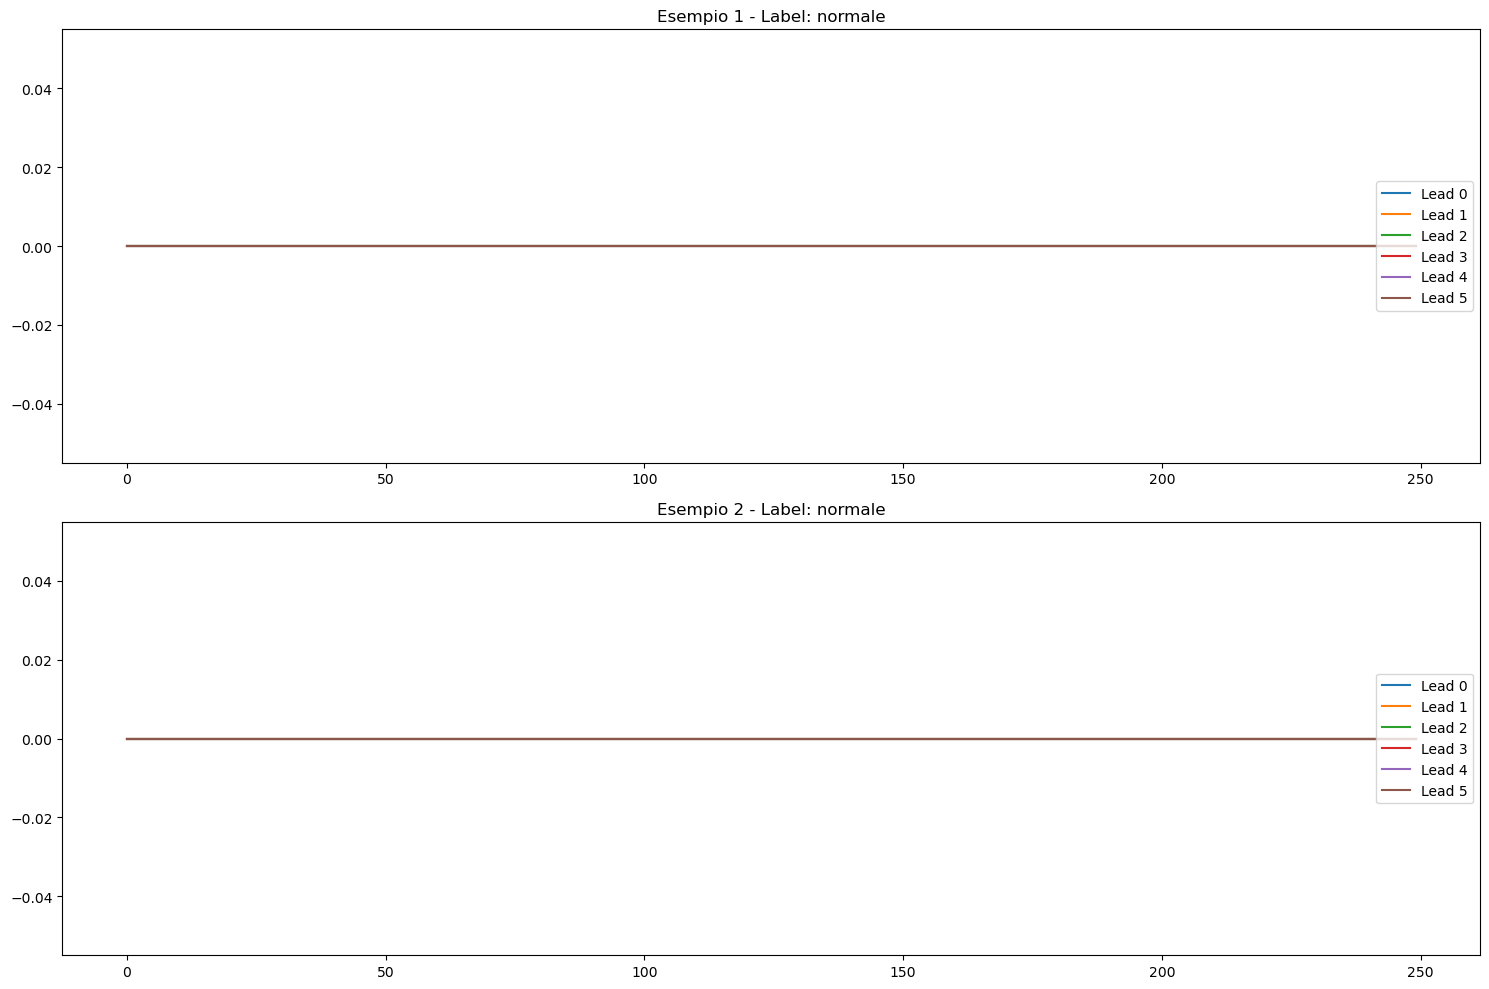

Valori minimi/massimi esempio 1: 0.0 / 0.0


In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Carichiamo un pezzetto del dataset per vedere se è sano
with h5py.File("train_dataset.h5", 'r') as f:
    x_raw = f['X'][:100] # Prendiamo i primi 100 esempi
    y_raw = f['Y'][:100]

# Decodifichiamo le etichette se sono in formato bytes
y_labels = [l.decode('utf-8') if isinstance(l, bytes) else str(l) for l in y_raw]

# Scegliamo due indici: uno 'normale' e uno con un'inversione (se esiste nei primi 100)
idx_1 = 0 
idx_2 = 10 # Proviamo il decimo

plt.figure(figsize=(15, 10))

# Visualizziamo il primo esempio
plt.subplot(2, 1, 1)
for i in range(6): # Mostriamo le 6 derivazioni periferiche
    plt.plot(x_raw[idx_1, i, :], label=f"Lead {i}")
plt.title(f"Esempio 1 - Label: {y_labels[idx_1]}")
plt.legend(loc='right')

# Visualizziamo il secondo esempio
plt.subplot(2, 1, 2)
for i in range(6):
    plt.plot(x_raw[idx_2, i, :], label=f"Lead {i}")
plt.title(f"Esempio 2 - Label: {y_labels[idx_2]}")
plt.legend(loc='right')

plt.tight_layout()
plt.show()

print(f"Valori minimi/massimi esempio 1: {x_raw[idx_1].min()} / {x_raw[idx_1].max()}")

In [4]:
# Scegli un ID che sai essere presente
test_id = df_valido['Num'].iloc[0] 
raw_data = get_ecg_from_s3(test_id)

print(f"Chiavi disponibili in raw_data: {list(raw_data.keys())}")

# Testiamo una lead (es. la 'I')
signal_I = raw_data['I']
print(f"Segnale RAW 'I' - Max: {np.max(signal_I)}, Min: {np.min(signal_I)}")

# Applichiamo il tuo preprocessing passo passo
b, a = signal.butter(5, [0.5, 35], btype='bandpass', fs=500) # Assumo 500Hz
clean = signal.filtfilt(b, a, signal_I)
print(f"Dopo Filtro - Max: {np.max(clean)}, Min: {np.min(clean)}")

resampled = signal.decimate(clean, 4)
std_val = np.std(resampled)
print(f"Deviazione Standard (std_val): {std_val}")

if not (1e-6 < std_val < 1e6):
    print("!!! ATTENZIONE: Il segnale è stato azzerato dal controllo std_val !!!")

NameError: name 'df_valido' is not defined